In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import os, random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [12]:
!unzip "/content/drive/MyDrive/Insect Classification-20260430T073507Z-3-001.zip"


Archive:  /content/drive/MyDrive/Insect Classification-20260430T073507Z-3-001.zip
replace Insect Classification/test/aphids/jpg_56.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [13]:
!ls /content

 drive	'Insect Classification'   sample_data


In [14]:
base_path = "/content/Insect Classification"
print(os.listdir(base_path))

['train', 'test']


In [15]:
print(os.listdir(base_path + "/train"))
print(os.listdir(base_path + "/test"))

['stem_borer', 'sawfly', 'grasshopper', 'armyworm', 'aphids', 'mites', 'bollworm', 'beetle', 'mosquito']
['stem_borer', 'sawfly', 'grasshopper', 'armyworm', 'aphids', 'mites', 'bollworm', 'beetle', 'mosquito']


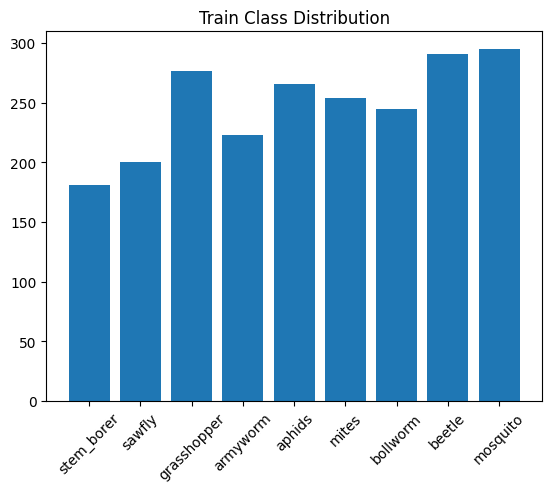

In [16]:
train_path = base_path + "/train"

class_counts = {
    cls: len(os.listdir(os.path.join(train_path, cls)))
    for cls in os.listdir(train_path)
}

plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45)
plt.title("Train Class Distribution")
plt.show()

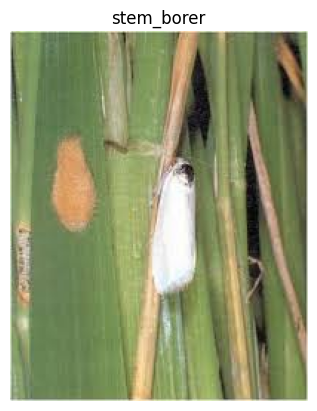

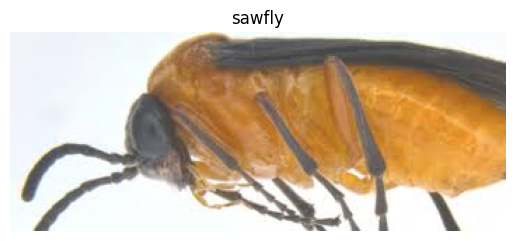

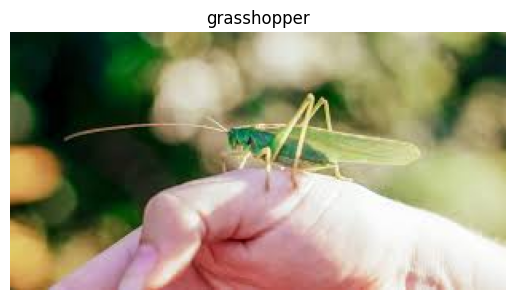

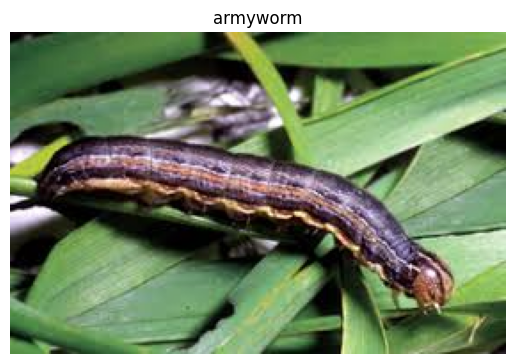

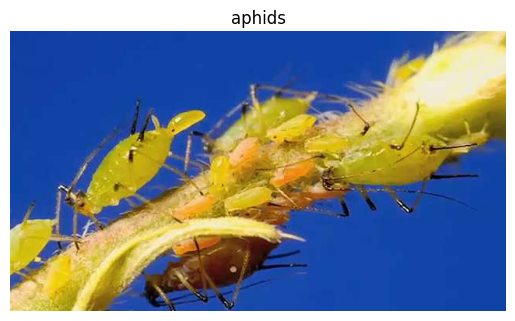

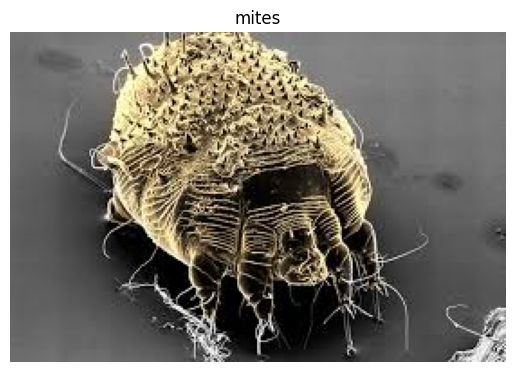

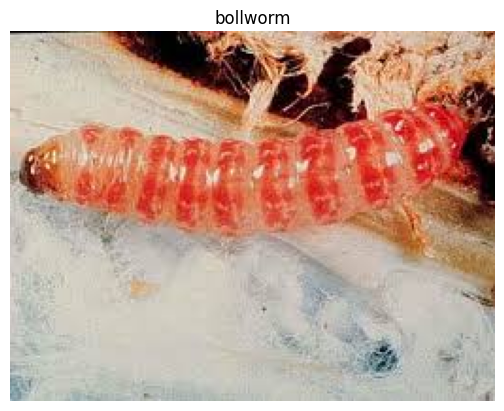

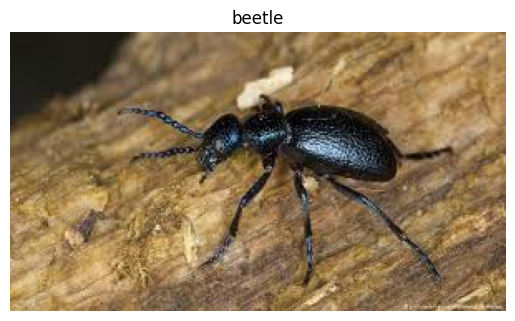

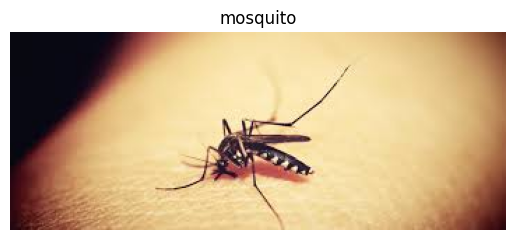

In [17]:
from PIL import Image
import random

for cls in os.listdir(train_path):
    img_name = random.choice(os.listdir(os.path.join(train_path, cls)))
    img = Image.open(os.path.join(train_path, cls, img_name))
    plt.imshow(img); plt.title(cls); plt.axis('off'); plt.show()

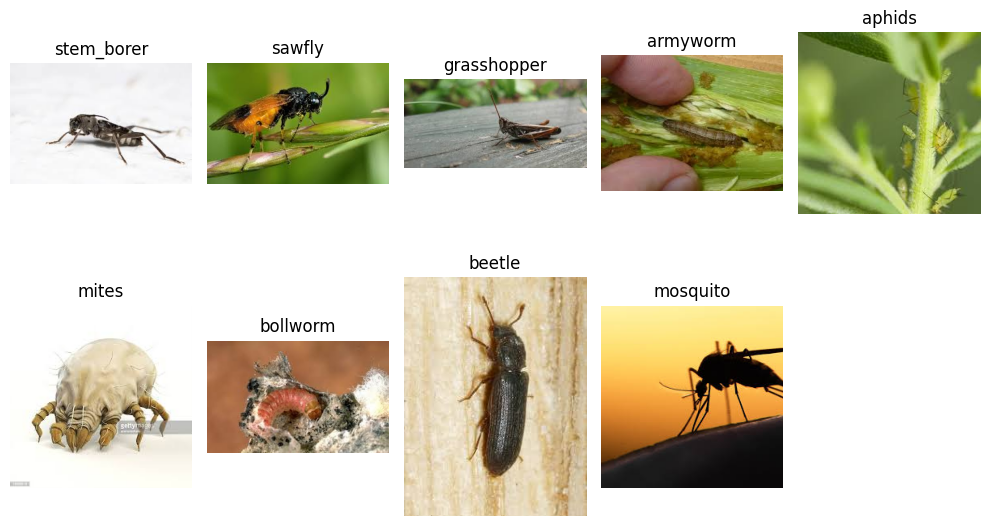

In [18]:
plt.figure(figsize=(10,6))
i = 1
for cls in os.listdir(train_path):
    img_name = random.choice(os.listdir(os.path.join(train_path, cls)))
    img = Image.open(os.path.join(train_path, cls, img_name))
    plt.subplot(2, len(os.listdir(train_path))//2 + 1, i)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')
    i += 1
plt.tight_layout()
plt.show()

In [19]:
for cls in os.listdir(train_path):
    cls_path = os.path.join(train_path, cls)

    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()  # checks integrity
        except:
            print("Deleting corrupted:", img_path)
            os.remove(img_path)

Deleting corrupted: /content/Insect Classification/train/stem_borer/jpg_9 - Copy (2).jpg
Deleting corrupted: /content/Insect Classification/train/stem_borer/jpg_11.jpg
Deleting corrupted: /content/Insect Classification/train/stem_borer/jpg_65 - Copy (2).jpg
Deleting corrupted: /content/Insect Classification/train/stem_borer/jpg_1.jpg
Deleting corrupted: /content/Insect Classification/train/stem_borer/jpg_97.jpg
Deleting corrupted: /content/Insect Classification/train/stem_borer/jpg_27 - Copy (2).jpg
Deleting corrupted: /content/Insect Classification/train/stem_borer/jpg_65 - Copy (2) - Copy.jpg
Deleting corrupted: /content/Insect Classification/train/stem_borer/jpg_49 - Copy.jpg
Deleting corrupted: /content/Insect Classification/train/stem_borer/jpg_38.jpg
Deleting corrupted: /content/Insect Classification/train/stem_borer/jpg_56 - Copy.jpg
Deleting corrupted: /content/Insect Classification/train/stem_borer/jpg_0 - Copy.jpg
Deleting corrupted: /content/Insect Classification/train/stem_

In [20]:
train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [21]:
test_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [22]:
data_dir = "/content/Insect Classification"

train_data = datasets.ImageFolder(data_dir + "/train", transform=train_tfms)
test_data  = datasets.ImageFolder(data_dir + "/test", transform=test_tfms)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=32)

class_names = train_data.classes
num_classes = len(class_names)

print("Classes:", class_names)

Classes: ['aphids', 'armyworm', 'beetle', 'bollworm', 'grasshopper', 'mites', 'mosquito', 'sawfly', 'stem_borer']


In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights="IMAGENET1K_V1")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 147MB/s]


In [24]:
for param in model.parameters():
    param.requires_grad = False

In [25]:
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

In [26]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

In [27]:
train_losses = []
val_accuracies = []

def evaluate(loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            preds = out.argmax(1)
            total += y.size(0)
            correct += (preds == y).sum().item()
    return correct / total

for epoch in range(5):
    model.train()
    running_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    val_acc = evaluate(test_loader)

    train_losses.append(avg_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f}")

Epoch 1 | Loss: 1.6302 | Val Acc: 0.7005
Epoch 2 | Loss: 0.9816 | Val Acc: 0.8203
Epoch 3 | Loss: 0.7622 | Val Acc: 0.8750
Epoch 4 | Loss: 0.6538 | Val Acc: 0.8776
Epoch 5 | Loss: 0.5814 | Val Acc: 0.8906


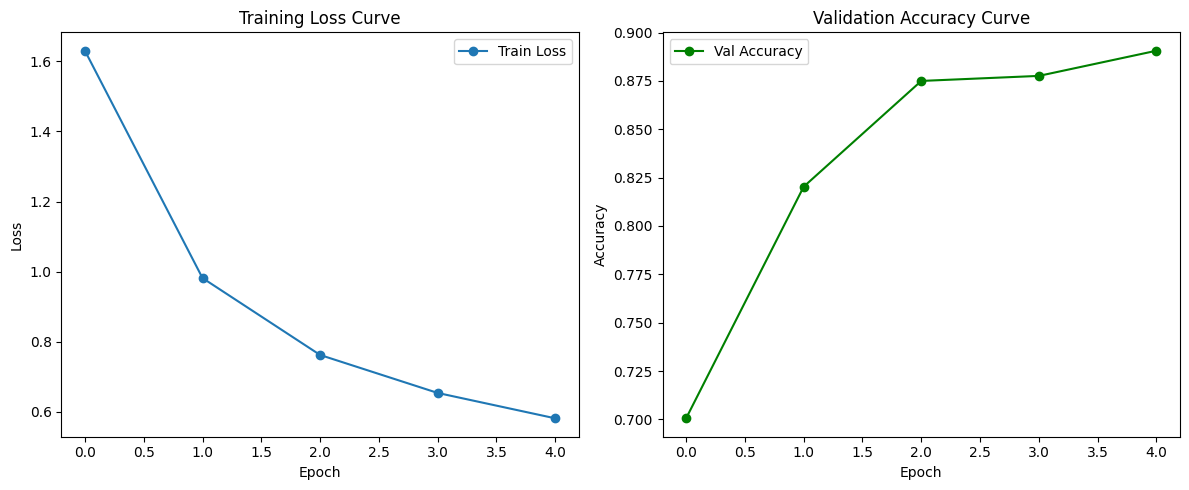

In [28]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', marker='o')
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Val Accuracy', color='green', marker='o')
plt.title('Validation Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [29]:
# Unfreeze last block
for name, param in model.named_parameters():
    if "layer4" in name:
        param.requires_grad = True

optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

In [30]:
for epoch in range(3):
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()

    print(f"Fine-tune Epoch {epoch+1} done")

Fine-tune Epoch 1 done
Fine-tune Epoch 2 done
Fine-tune Epoch 3 done


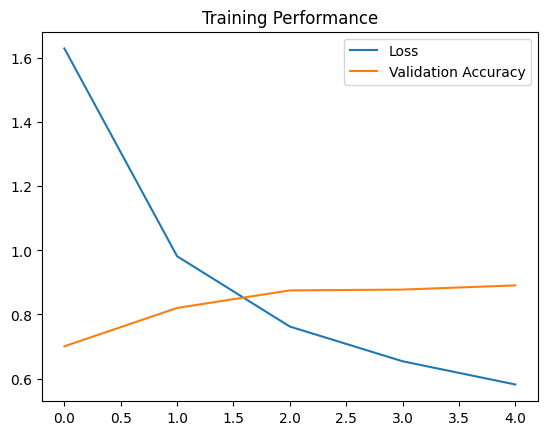

In [31]:
plt.figure()
plt.plot(train_losses, label="Loss")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.legend()
plt.title("Training Performance")
plt.show()

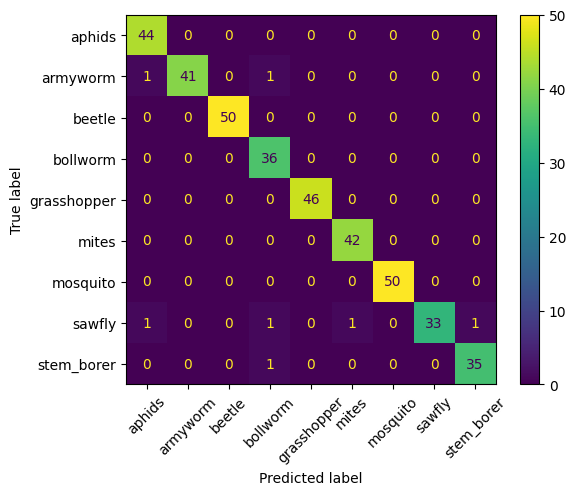

              precision    recall  f1-score   support

      aphids       0.96      1.00      0.98        44
    armyworm       1.00      0.95      0.98        43
      beetle       1.00      1.00      1.00        50
    bollworm       0.92      1.00      0.96        36
 grasshopper       1.00      1.00      1.00        46
       mites       0.98      1.00      0.99        42
    mosquito       1.00      1.00      1.00        50
      sawfly       1.00      0.89      0.94        37
  stem_borer       0.97      0.97      0.97        36

    accuracy                           0.98       384
   macro avg       0.98      0.98      0.98       384
weighted avg       0.98      0.98      0.98       384



In [32]:
all_preds, all_labels = [], []

model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        preds = model(x).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(xticks_rotation=45)
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names))